In [1]:
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt

# Load and Standardize
iris = load_iris()
scaler = StandardScaler()
features_standardized = scaler.fit_transform(iris.data)


In [2]:
pca = PCA(n_components=2)
features_pca = pca.fit_transform(features_standardized)

pca_df = pd.DataFrame(data=features_pca, columns=["PC 1", "PC 2"])
pca_df["Target"] = iris.target

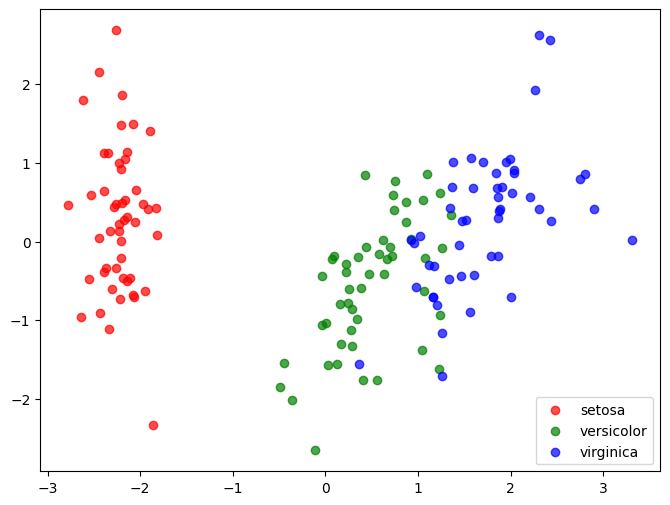

Variance Retained: 0.9581320720000166


In [3]:
plt.figure(figsize=(8, 6))
for label, color in zip(iris.target_names, ["red", "green", "blue"]):
    plt.scatter(
        pca_df.loc[pca_df["Target"] == list(iris.target_names).index(label), "PC 1"],
        pca_df.loc[pca_df["Target"] == list(iris.target_names).index(label), "PC 2"],
        c=color, label=label, alpha=0.7
    )
plt.legend()
plt.show()

print("Variance Retained:", sum(pca.explained_variance_ratio_))

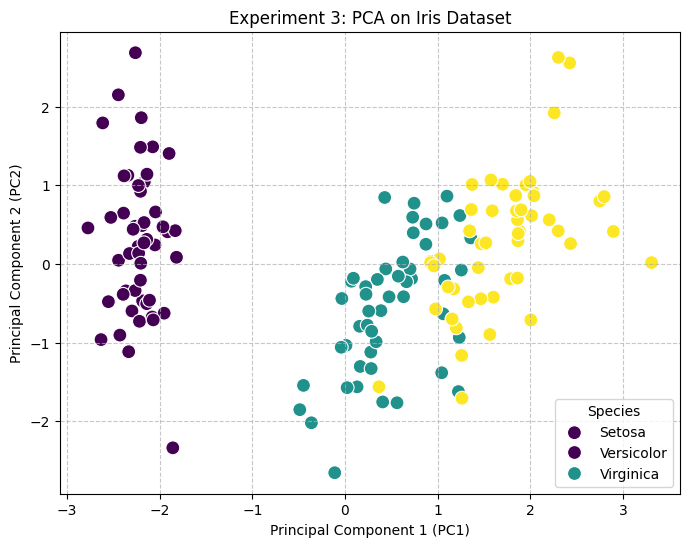

Explained Variance Ratio: [0.72962445 0.22850762]


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names

# 2. Standardize the data (PCA works best when data is scaled)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Apply PCA to reduce 4 features to 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 4. Create a DataFrame for plotting
df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df['Species'] = y

# 5. Visualization
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='PC1', y='PC2', hue='Species', palette='viridis', s=100)

# --- This is the part you needed ---
plt.grid(True, linestyle='--', alpha=0.7) # Adds the dashed grid lines
# -----------------------------------

plt.title('Experiment 3: PCA on Iris Dataset')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.legend(title='Species', labels=['Setosa', 'Versicolor', 'Virginica'])
plt.show()

# Print explained variance ratio
print(f"Explained Variance Ratio: {pca.explained_variance_ratio_}")